In [1]:
import pandas as pd

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = pd.read_csv("Datasets/final_dataset.csv")

lyrics_cols = [str(i) for i in range(384)]

features = df[lyrics_cols]
target = df['mood']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Calm       0.00      0.00      0.00       201
   Energetic       0.53      0.83      0.64      1900
         Sad       1.00      0.00      0.01       391
    Stressed       0.48      0.31      0.37      1397

    accuracy                           0.51      3889
   macro avg       0.50      0.28      0.26      3889
weighted avg       0.53      0.51      0.45      3889



C:\Users\burcu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\burcu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\burcu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


RANDOM FOREST CLASS WEIGHT

In [7]:
df = pd.read_csv("Datasets/final_dataset.csv")

lyrics_cols = [str(i) for i in range(384)]

features = df[lyrics_cols]
target = df['mood']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)

model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Calm       0.00      0.00      0.00       201
   Energetic       0.52      0.87      0.65      1900
         Sad       0.00      0.00      0.00       391
    Stressed       0.48      0.24      0.32      1397

    accuracy                           0.51      3889
   macro avg       0.25      0.28      0.24      3889
weighted avg       0.42      0.51      0.43      3889



C:\Users\burcu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\burcu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\burcu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


HYPERPARAMETER TUNING

In [8]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=8, 
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters Found:", random_search.best_params_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters Found: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 357}
              precision    recall  f1-score   support

        Calm       0.50      0.01      0.02       201
   Energetic       0.57      0.61      0.59      1900
         Sad       0.17      0.18      0.17       391
    Stressed       0.45      0.46      0.46      1397

    accuracy                           0.48      3889
   macro avg       0.42      0.32      0.31      3889
weighted avg       0.48      0.48      0.47      3889



SMOTE OVERSAMPLING

In [9]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

best_params = {
    'n_estimators': 357,
    'max_depth': 10,
    'max_features': 'log2',
    'min_samples_leaf': 4,
    'min_samples_split': 5
}

best_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42
)

best_model.fit(X_resampled, y_resampled)

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(Counter(y_train))
print(Counter(y_resampled))

              precision    recall  f1-score   support

        Calm       0.10      0.16      0.13       201
   Energetic       0.59      0.53      0.56      1900
         Sad       0.16      0.29      0.20       391
    Stressed       0.47      0.38      0.42      1397

    accuracy                           0.43      3889
   macro avg       0.33      0.34      0.33      3889
weighted avg       0.48      0.43      0.45      3889

Counter({'Energetic': 7599, 'Stressed': 5588, 'Sad': 1562, 'Calm': 805})
Counter({'Stressed': 7599, 'Energetic': 7599, 'Sad': 7599, 'Calm': 7599})


ADASYN OVERSAMPLING

In [10]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)

best_params = {
    'n_estimators': 357,
    'max_depth': 10,
    'max_features': 'log2',
    'min_samples_leaf': 4,
    'min_samples_split': 5
}

best_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42
)

best_model.fit(X_resampled, y_resampled)

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(Counter(y_train))
print(Counter(y_resampled))

              precision    recall  f1-score   support

        Calm       0.11      0.14      0.12       201
   Energetic       0.59      0.55      0.57      1900
         Sad       0.15      0.34      0.21       391
    Stressed       0.46      0.33      0.39      1397

    accuracy                           0.43      3889
   macro avg       0.33      0.34      0.32      3889
weighted avg       0.48      0.43      0.44      3889

Counter({'Energetic': 7599, 'Stressed': 5588, 'Sad': 1562, 'Calm': 805})
Counter({'Sad': 8233, 'Energetic': 7599, 'Stressed': 7400, 'Calm': 7395})


SMOTEENN OVERSAMPLING

In [11]:
from imblearn.combine import SMOTEENN

smoteenn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smoteenn.fit_resample(X_train, y_train)

best_params = {
    'n_estimators': 357,
    'max_depth': 10,
    'max_features': 'log2',
    'min_samples_leaf': 4,
    'min_samples_split': 5
}

best_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42
)

best_model.fit(X_resampled, y_resampled)

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(Counter(y_train))
print(Counter(y_resampled))

              precision    recall  f1-score   support

        Calm       0.07      0.45      0.12       201
   Energetic       0.83      0.04      0.07      1900
         Sad       0.14      0.44      0.21       391
    Stressed       0.44      0.41      0.42      1397

    accuracy                           0.23      3889
   macro avg       0.37      0.33      0.21      3889
weighted avg       0.58      0.23      0.21      3889

Counter({'Energetic': 7599, 'Stressed': 5588, 'Sad': 1562, 'Calm': 805})
Counter({'Calm': 7590, 'Sad': 7389, 'Stressed': 2417, 'Energetic': 309})


FEATURE IMPORTANCE 

C:\Users\burcu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\burcu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\burcu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        Calm       0.00      0.00      0.00       201
   Energetic       0.53      0.83      0.64      1900
         Sad       1.00      0.00      0.01       391
    Stressed       0.48      0.31      0.37      1397

    accuracy                           0.51      3889
   macro avg       0.50      0.28      0.26      3889
weighted avg       0.53      0.51      0.45      3889



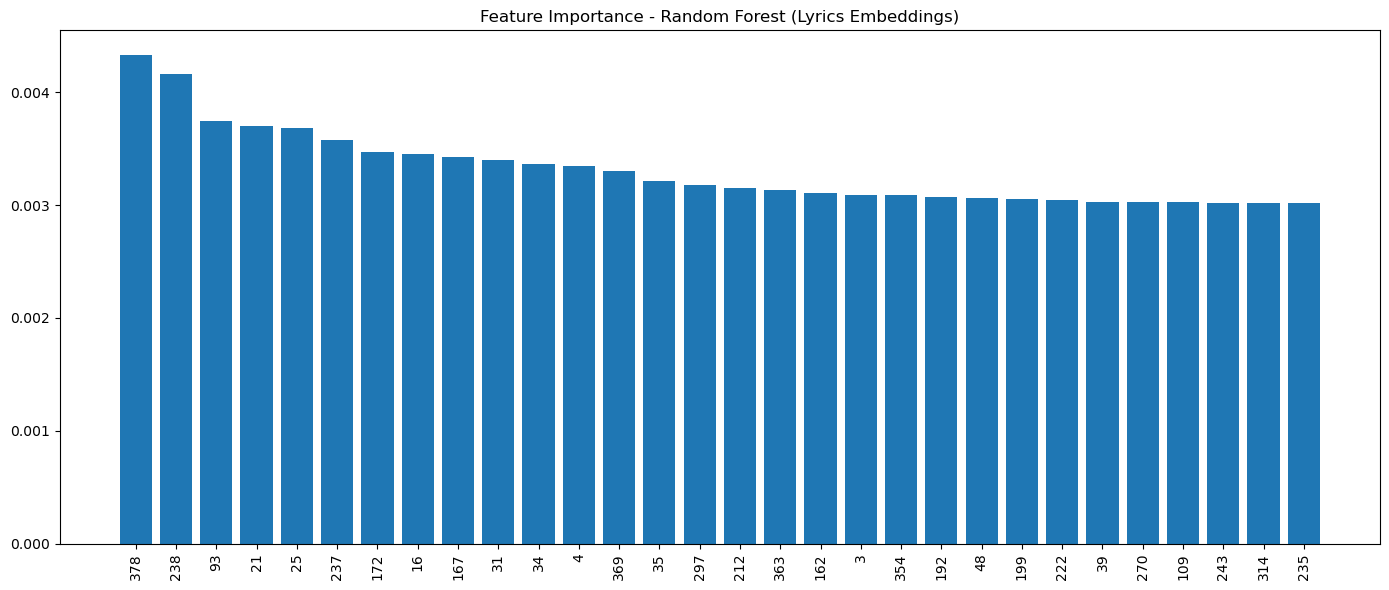

In [12]:
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Datasets/final_dataset.csv")

lyrics_cols = [str(i) for i in range(384)]
features = df[lyrics_cols]
target = df['mood']

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

importances = model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(14, 6))
plt.title("Feature Importance - Random Forest (Lyrics Embeddings)")
plt.bar(range(30), importances[indices[:30]])  # En önemli 30 özelliği göster
plt.xticks(range(30), feature_names[indices[:30]], rotation=90)
plt.tight_layout()
plt.show()

XGBOOST

C:\Users\burcu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:22:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 Classification Report (XGBoost):
              precision    recall  f1-score   support

        Calm       0.00      0.00      0.00       201
   Energetic       0.54      0.73      0.62      1900
         Sad       0.12      0.01      0.01       391
    Stressed       0.46      0.44      0.45      1397

    accuracy                           0.51      3889
   macro avg       0.28      0.29      0.27      3889
weighted avg       0.44      0.51      0.47      3889



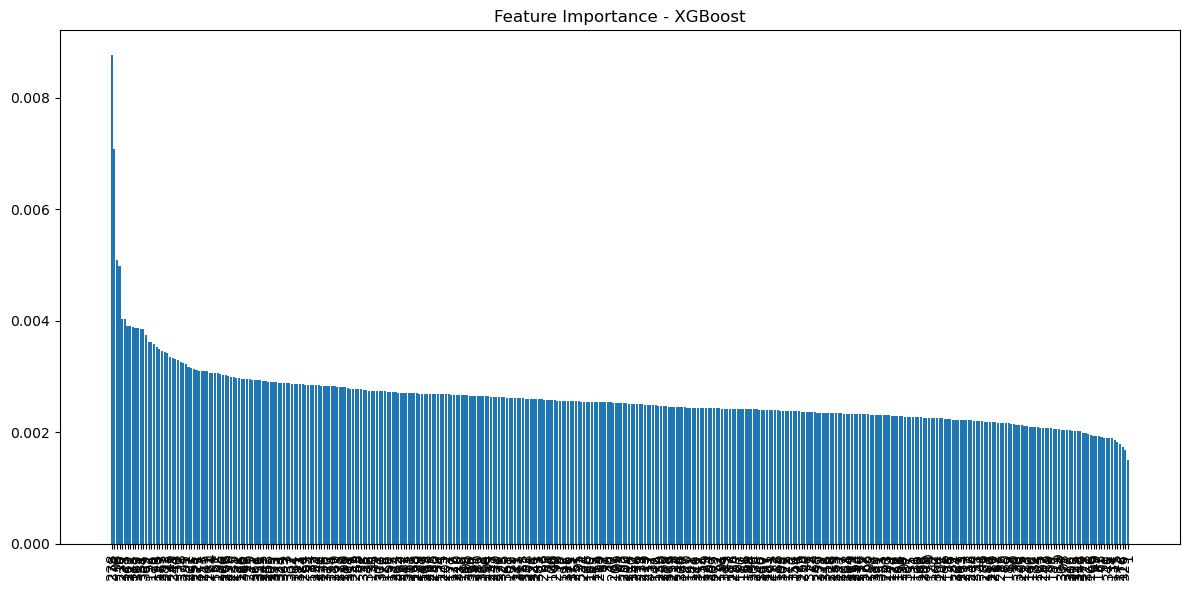

In [13]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

xgb_model.fit(X_train, y_train_encoded)

y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("📊 Classification Report (XGBoost):")
print(classification_report(y_test, y_pred))

importances = xgb_model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importance - XGBoost")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

XGBOOST WITH CLASS WEIGHT

In [14]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

xgb_model.fit(X_train, y_train_encoded, sample_weight=sample_weights)

y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print(classification_report(y_test, y_pred))

C:\Users\burcu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:23:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

        Calm       0.17      0.02      0.04       201
   Energetic       0.56      0.64      0.59      1900
         Sad       0.15      0.07      0.09       391
    Stressed       0.45      0.49      0.47      1397

    accuracy                           0.49      3889
   macro avg       0.33      0.30      0.30      3889
weighted avg       0.46      0.49      0.47      3889



HYPERPARAMETER TUNING

In [15]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2, 0.5]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=8,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    n_jobs=1,
    random_state=42
)


random_search.fit(X_train, y_train_encoded, sample_weight=sample_weights)

print("✅ Best Parameters Found:")
print(random_search.best_params_)

from sklearn.metrics import classification_report
y_pred_encoded = random_search.best_estimator_.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("\n📊 Classification Report (XGBoost - Tuned):")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 8 candidates, totalling 24 fits


C:\Users\burcu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:24:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.2, max_depth=10, min_child_weight=5, n_estimators=200, subsample=1.0; total time= 1.1min


C:\Users\burcu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:25:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.2, max_depth=10, min_child_weight=5, n_estimators=200, subsample=1.0; total time= 1.0min


...

[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.2, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.6; total time=  29.6s


C:\Users\burcu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:58:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.2, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.6; total time=  31.1s


C:\Users\burcu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:58:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Best Parameters Found:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}

📊 Classification Report (XGBoost - Tuned):
              precision    recall  f1-score   support

        Calm       0.42      0.02      0.05       201
   Energetic       0.59      0.64      0.61      1900
         Sad       0.22      0.11      0.14       391
    Stressed       0.46      0.53      0.49      1397

    accuracy                           0.52      3889
   macro avg       0.42      0.33      0.32      3889
weighted avg       0.49      0.52      0.49      3889



In [16]:
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train_encoded)

print("📊 Resampled class distribution after SMOTE:")
print(Counter(y_smote))

for label, count in Counter(y_smote).items():
    print(f"{le.inverse_transform([label])[0]}: {count}")

sample_weights_smote = compute_sample_weight(class_weight='balanced', y=y_smote)

best_params = {
    'n_estimators': 300,
    'max_depth': 10,
    'learning_rate': 0.01,
    'subsample': 0.8,
    'gamma': 0.2,
    'colsample_bytree': 1.0,
    'min_child_weight': 5
}

model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    **best_params
)

model.fit(X_smote, y_smote, sample_weight=sample_weights_smote)

y_pred_encoded = model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("\n📊 Classification Report (XGBoost + SMOTE):")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy with SMOTE: {round(acc, 4)}")


📊 Resampled class distribution after SMOTE:
Counter({3: 7599, 1: 7599, 2: 7599, 0: 7599})
Stressed: 7599
Energetic: 7599
Sad: 7599
Calm: 7599


C:\Users\burcu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:05:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Classification Report (XGBoost + SMOTE):
              precision    recall  f1-score   support

        Calm       0.10      0.10      0.10       201
   Energetic       0.60      0.59      0.59      1900
         Sad       0.18      0.21      0.20       391
    Stressed       0.48      0.46      0.47      1397

    accuracy                           0.48      3889
   macro avg       0.34      0.34      0.34      3889
weighted avg       0.49      0.48      0.48      3889

✅ Accuracy with SMOTE: 0.4788


In [17]:
from imblearn.over_sampling import ADASYN
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
import xgboost as xgb

adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train_encoded)


from collections import Counter


sample_weights = compute_sample_weight(class_weight='balanced', y=y_resampled)

best_params = {
    'n_estimators': 300,
    'max_depth': 10,
    'learning_rate': 0.01,
    'subsample': 0.8,
    'gamma': 0.2,
    'colsample_bytree': 1.0,
    'min_child_weight': 5
}

model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    **best_params
)

model.fit(X_resampled, y_resampled, sample_weight=sample_weights)

y_pred_encoded = model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("\n📊 Classification Report (XGBoost + ADASYN):")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy with ADASYN: {round(acc, 4)}")

print("📊 Resampled class distribution after SMOTE:")
print(Counter(y_resampled))

for label, count in Counter(y_resampled).items():
    print(f"{le.inverse_transform([label])[0]}: {count}")

C:\Users\burcu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:14:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Classification Report (XGBoost + ADASYN):
              precision    recall  f1-score   support

        Calm       0.10      0.10      0.10       201
   Energetic       0.59      0.59      0.59      1900
         Sad       0.19      0.25      0.22       391
    Stressed       0.48      0.44      0.46      1397

    accuracy                           0.48      3889
   macro avg       0.34      0.35      0.34      3889
weighted avg       0.49      0.48      0.48      3889

✅ Accuracy with ADASYN: 0.4775
📊 Resampled class distribution after SMOTE:
Counter({2: 8233, 1: 7599, 3: 7400, 0: 7395})
Stressed: 7400
Energetic: 7599
Sad: 8233
Calm: 7395
